In [1]:
import sqlite3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from math import sqrt
from sklearn import preprocessing
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import numpy as np

## Creacion de la conexion a la base de datos para leer la tabla "Player Attributes"

De donde se descargo el dataset
https://www.kaggle.com/datasets/hugomathien/soccer?resource=download

In [12]:
cnx = sqlite3.connect('F:/Diplomado-RNA/Modulo-2/Notebooks/DataSets/database.sqlite')

In [13]:
df = pd.read_sql_query("SELECT * FROM Player_Attributes", cnx)

In [14]:
df.head()

,id,player_fifa_api_id,player_api_id,date,overall_rating,potential,preferred_foot,attacking_work_rate,defensive_work_rate,crossing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,1,218353,505942,2016-02-18 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,2,218353,505942,2015-11-19 00:00:00,67.0,71.0,right,medium,medium,49.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,3,218353,505942,2015-09-21 00:00:00,62.0,66.0,right,medium,medium,49.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,4,218353,505942,2015-03-20 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,5,218353,505942,2007-02-22 00:00:00,61.0,65.0,right,medium,medium,48.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


In [15]:
df.shape

(183978, 42)

In [16]:
df.columns

Index(['id', 'player_fifa_api_id', 'player_api_id', 'date', 'overall_rating',
       'potential', 'preferred_foot', 'attacking_work_rate',
       'defensive_work_rate', 'crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes'],
      dtype='str')

###  De todas las columnas, determinaremos cuales se usaran con "Features" para alimentar al modelo

In [21]:
features = ['potential','crossing', 'finishing', 'heading_accuracy',
       'short_passing', 'volleys', 'dribbling', 'curve', 'free_kick_accuracy',
       'long_passing', 'ball_control', 'acceleration', 'sprint_speed',
       'agility', 'reactions', 'balance', 'shot_power', 'jumping', 'stamina',
       'strength', 'long_shots', 'aggression', 'interceptions', 'positioning',
       'vision', 'penalties', 'marking', 'standing_tackle', 'sliding_tackle',
       'gk_diving', 'gk_handling', 'gk_kicking', 'gk_positioning',
       'gk_reflexes']

## Seleccionamos el target

In [18]:
target = ['overall_rating']

### Limpiar los datos eliminando filas con valores "nan"

In [19]:
df = df.dropna()

### Separamos las caracteristicas "Features" en X, el target en Y

In [22]:
x = df[features]
y = df[target]

### Mostrar el contenido de una fila del conjunto X

In [25]:
x.iloc[2000]

potential             73.0
crossing              69.0
finishing             35.0
heading_accuracy      55.0
short_passing         63.0
volleys               41.0
dribbling             58.0
curve                 58.0
free_kick_accuracy    29.0
long_passing          58.0
ball_control          63.0
acceleration          83.0
sprint_speed          71.0
agility               58.0
reactions             54.0
balance               74.0
shot_power            65.0
jumping               59.0
stamina               74.0
strength              57.0
long_shots            50.0
aggression            57.0
interceptions         57.0
positioning           48.0
vision                42.0
penalties             43.0
marking               67.0
standing_tackle       66.0
sliding_tackle        65.0
gk_diving             12.0
gk_handling           11.0
gk_kicking            10.0
gk_positioning        13.0
gk_reflexes           12.0
Name: 2043, dtype: float64

In [26]:
x.head()

,potential,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,free_kick_accuracy,long_passing,...,vision,penalties,marking,standing_tackle,sliding_tackle,gk_diving,gk_handling,gk_kicking,gk_positioning,gk_reflexes
0,71.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
1,71.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,...,54.0,48.0,65.0,69.0,69.0,6.0,11.0,10.0,8.0,8.0
2,66.0,49.0,44.0,71.0,61.0,44.0,51.0,45.0,39.0,64.0,...,54.0,48.0,65.0,66.0,69.0,6.0,11.0,10.0,8.0,8.0
3,65.0,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0
4,65.0,48.0,43.0,70.0,60.0,43.0,50.0,44.0,38.0,63.0,...,53.0,47.0,62.0,63.0,66.0,5.0,10.0,9.0,7.0,7.0


In [27]:
y.head()

,overall_rating
0,67.0
1,67.0
2,62.0
3,61.0
4,61.0


### Muestreo de los valores de la feature "reaction" para cada jugador

In [28]:
x['reactions']

0         47.0
1         47.0
2         47.0
3         46.0
4         46.0
          ... 
183973    86.0
183974    74.0
183975    74.0
183976    69.0
183977    66.0
Name: reactions, Length: 180354, dtype: float64

### Imprimir la relacion existente entre el feature "reactions" y el target "Overall_rating"

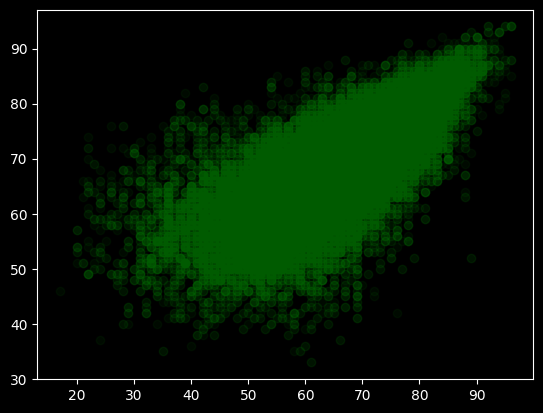

In [29]:
plt.scatter(x['reactions'], y , color='darkgreen',label='Datos',alpha=0.1)

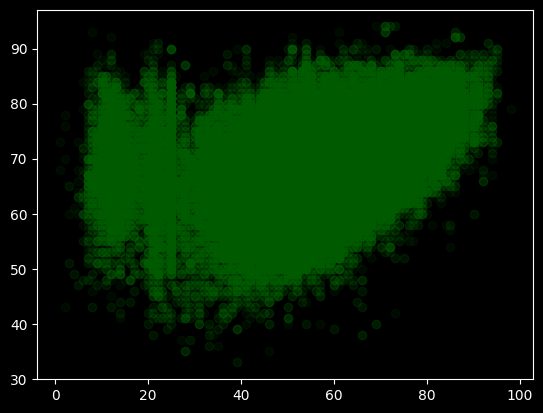

In [30]:
plt.scatter(x['heading_accuracy'], y , color='darkgreen',label='Datos',alpha=0.1)

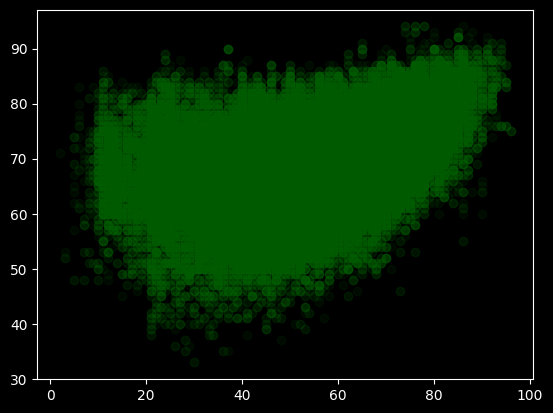

In [31]:
plt.scatter(x['penalties'], y , color='darkgreen',label='Datos',alpha=0.1)

### Separacion de los datos en Training y Test Datasets

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.33, random_state = 324)

### Utilizar un escalador estandar
Para que los datos de cada feature se cople a un rango y se eviten os sesgos de un feature con valores muy altos que puedan influir de mas en el target

In [33]:
scale = preprocessing.StandardScaler()

### Entrenar con los datos escalados

In [34]:
scale.fit(x_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [35]:
x_train = scale.transform(x_train)

# imprimir los nuevos valores minimo y maximo de las caracteristicas "features" de entrenamiento

In [36]:
x_train.min()

np.float64(-5.377337896778157)

In [37]:
x_train.max()

np.float64(4.9683467491419835)

### Creamos una instancia del modelo de Regresion lineal de scikit Learn

In [38]:
regresor = LinearRegression()

# Ajustamos el modelo a los datos de entrenamiento

In [39]:
regresor.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Reaizar una prediccion usando e conjunto de datos de prueba(test set)
Escalar los valores de prueba para que coincidan con los datos de entrenamiento

In [40]:
x_test = scale.transform(x_test)

# Hacer una prediccion de el valor de salida, pasandole los valores de prueba

In [41]:
y_prediccion = regresor.predict(x_test)

# Obtener la diferiencia de lo que hay entre los valores de salida predichos contra los valores de salida reales

In [42]:
y_result = y_prediccion - y_test
y_result

,overall_rating
35543,0.512849
28735,-3.227654
168029,1.573718
138117,0.990422
123316,1.203533
...,...
51151,-1.920947
155333,-1.253060
118067,-1.762199
62126,2.583517


### Calcular la raiz cuadrada del Error Cuadratico Medio

In [43]:
RMSE = sqrt(mean_squared_error(y_true=y_test, y_pred=y_prediccion))
print(RMSE)

2.805303046855211


### Mostrar la precision que obtuvo el modelo al predecir con los valores de prueba

In [44]:
regresor.score(x_test, y_test)

0.8412690897596594

### Mostrar cual es el valor de cada w que se aplico a cada feature (w * x) para que al sumar todos los productos nos de el puntaje de cada jugador

In [45]:
regresor.coef_

array([[ 2.48175418,  0.37435166,  0.2155902 ,  1.14537904,  0.72579619,
         0.08835762, -0.2396529 ,  0.20341906,  0.23070925,  0.08573083,
         2.03147644,  0.08063536,  0.11593773, -0.09744622,  1.92780373,
         0.10753058,  0.27833167,  0.16277628, -0.08089224,  0.73874625,
        -0.25048481,  0.33897633,  0.22293067, -0.18511046, -0.01892236,
         0.21517621,  0.70526674,  0.07880386, -0.61339243,  2.72376613,
         0.51832172, -0.70907673,  0.91420565,  0.43578429]])

In [46]:
regresor.intercept_

array([68.63507038])